<a href="https://colab.research.google.com/github/aniray2908/nlp-llm-journey/blob/main/01_nlp_fundamentals/demos/04_word_embeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Cell 1 — Imports & Setup**

In [1]:
!pip install gensim -q
!pip install matplotlib scikit-learn -q

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 44.7 MB/s eta 0:00:00


**Cell 2 — Load Pre-trained Word2Vec Embeddings**

In [3]:
from gensim.models import KeyedVectors
import gensim.downloader as api

print("Loading pre-trained Word2Vec embeddings...")
print("(This may take a minute on first run...)")

# Use gensim's built-in downloader for a smaller, available model
# Options: 'word2vec-google-news-300' (large), 'glove-wiki-gigaword-100' (smaller), etc.
word_vectors = api.load("glove-wiki-gigaword-100")

print(f"Loaded {len(word_vectors)} word vectors")
print(f"Embedding dimension: {word_vectors.vector_size}")

# Test: look up a word
vector = word_vectors['king']
print(f"\nVector for 'king': shape {vector.shape}")
print(f"First 10 dimensions: {vector[:10]}")

Loading pre-trained Word2Vec embeddings...
(This may take a minute on first run...)
[==================================================] 100.0% 128.1/128.1MB downloaded
Loaded 400000 word vectors
Embedding dimension: 100

Vector for 'king': shape (100,)
First 10 dimensions: [-0.32307 -0.87616  0.21977  0.25268  0.22976  0.7388  -0.37954 -0.35307
 -0.84369 -1.1113 ]


**Cell 3 — Finding Similar Words**

In [4]:
# Most similar words to a target word
def show_similar(word, topn=10):
    try:
        similar = word_vectors.most_similar(word, topn=topn)
        print(f"Words most similar to '{word}':")
        for w, score in similar:
            print(f"  {w:<20} {score:.3f}")
    except KeyError:
        print(f"Word '{word}' not in vocabulary")

# Try different categories
print("=" * 50)
show_similar('king')
print("\n" + "=" * 50)
show_similar('good')
print("\n" + "=" * 50)
show_similar('running')
print("\n" + "=" * 50)
show_similar('France')

Words most similar to 'king':
  prince               0.768
  queen                0.751
  son                  0.702
  brother              0.699
  monarch              0.698
  throne               0.692
  kingdom              0.681
  father               0.680
  emperor              0.671
  ii                   0.668

Words most similar to 'good':
  better               0.893
  sure                 0.831
  really               0.830
  kind                 0.829
  very                 0.826
  we                   0.823
  way                  0.822
  think                0.821
  thing                0.817
  're                  0.814

Words most similar to 'running':
  ran                  0.809
  run                  0.802
  line                 0.710
  going                0.704
  along                0.701
  out                  0.700
  now                  0.698
  back                 0.696
  instead              0.694
  behind               0.690

Word 'France' not in vocabulary


**Cell 4 — Word Analogies**

In [5]:
def show_analogy(word1, word2, word3, topn=5):
    """
    Solve: word1 is to word2 as word3 is to ?

    Mathematically: vector(word3) + (vector(word2) - vector(word1))
    """
    try:
        result = word_vectors.most_similar(
            positive=[word3, word2],
            negative=[word1],
            topn=topn
        )
        print(f"{word1} : {word2} :: {word3} : ?")
        for w, score in result:
            print(f"  {w:<20} {score:.3f}")
    except KeyError as e:
        print(f"Word not found: {e}")

# Classic analogy
print("=" * 60)
show_analogy('man', 'woman', 'king')

print("\n" + "=" * 60)
show_analogy('France', 'Paris', 'Germany')

print("\n" + "=" * 60)
show_analogy('bad', 'good', 'ugly')

print("\n" + "=" * 60)
show_analogy('run', 'running', 'walk')

# Try your own!
print("\n" + "=" * 60)
show_analogy('small', 'big', 'bad')

man : woman :: king : ?
  queen                0.770
  monarch              0.684
  throne               0.676
  daughter             0.659
  princess             0.652

Word not found: "Key 'Germany' not present in vocabulary"

bad : good :: ugly : ?
  wonderful            0.692
  look                 0.663
  pretty               0.662
  exciting             0.655
  nice                 0.650

run : running :: walk : ?
  walking              0.824
  sitting              0.666
  sit                  0.639
  waiting              0.636
  ride                 0.631

small : big :: bad : ?
  worse                0.701
  thing                0.699
  awful                0.674
  really               0.669
  n't                  0.666


**Cell 5 — Vector Arithmetic Visualisation**

In [6]:
# Get vectors for the king/queen example
king = word_vectors['king']
queen = word_vectors['queen']
man = word_vectors['man']
woman = word_vectors['woman']

# Compute differences
diff_royalty = king - queen      # difference between king and queen
diff_gender = woman - man        # difference between woman and man

# Are they similar? (should both represent gender/royalty)
similarity = np.dot(diff_royalty, diff_gender) / (np.linalg.norm(diff_royalty) * np.linalg.norm(diff_gender))
print(f"Similarity between (king-queen) and (woman-man): {similarity:.3f}")

# Now the reverse: man + diff_gender ≈ woman
woman_reconstructed = man + diff_gender
woman_actual = word_vectors['woman']

# Find closest word to the reconstructed vector
closest = word_vectors.most_similar(positive=[woman_reconstructed], topn=1)
print(f"\nman + (woman - man) ≈ {closest[0][0]} (score: {closest[0][1]:.3f})")
print(f"We wanted: woman")

Similarity between (king-queen) and (woman-man): -0.451

man + (woman - man) ≈ woman (score: 1.000)
We wanted: woman


**Cell 6 — Visualise Embeddings with PCA**

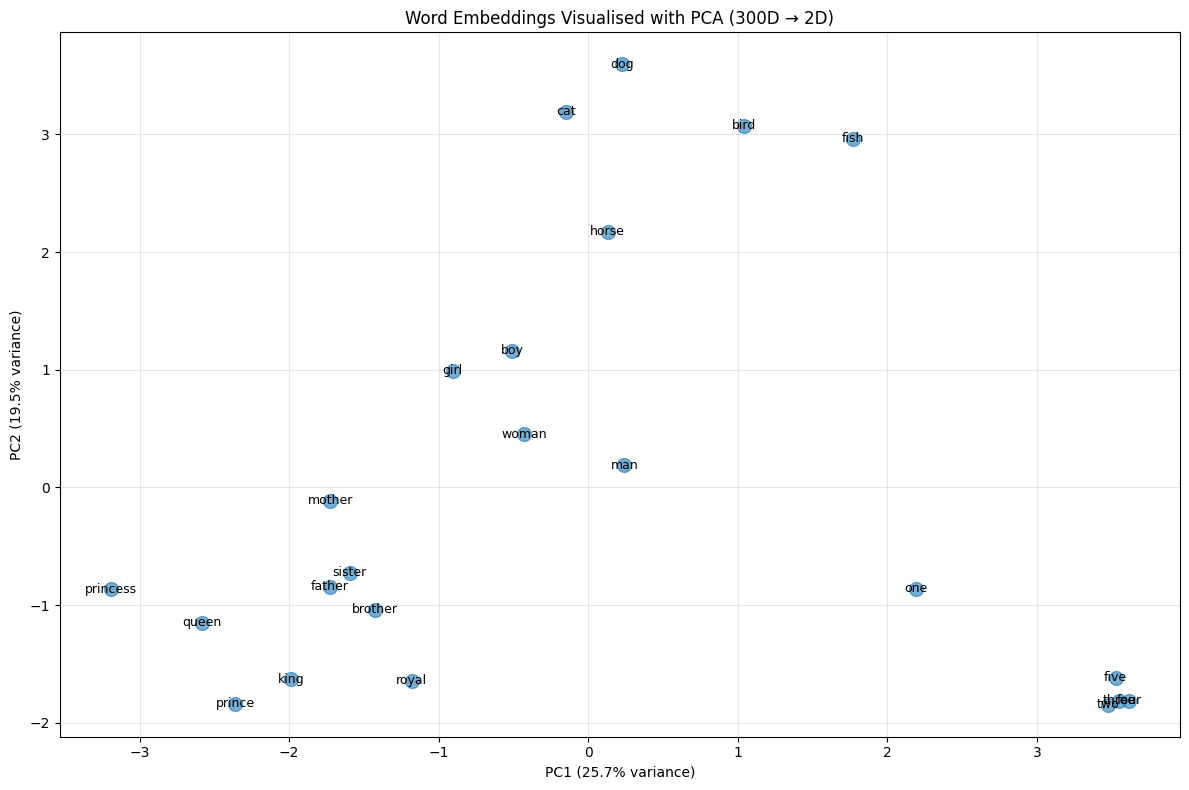

PCA explained variance: 45.3%
(2 dimensions capture ~45.3% of structure)


In [7]:
# Select a set of related words
words_to_plot = [
    # Royalty
    'king', 'queen', 'prince', 'princess', 'royal',
    # Family
    'man', 'woman', 'boy', 'girl', 'mother', 'father', 'sister', 'brother',
    # Animals
    'cat', 'dog', 'bird', 'fish', 'horse',
    # Numbers
    'one', 'two', 'three', 'four', 'five',
]

# Get vectors
vectors = np.array([word_vectors[w] for w in words_to_plot])

# Reduce to 2D with PCA
pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(vectors)

# Plot
plt.figure(figsize=(12, 8))
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], alpha=0.6, s=100)

# Label each point
for i, word in enumerate(words_to_plot):
    plt.annotate(word, (vectors_2d[i, 0], vectors_2d[i, 1]),
                fontsize=9, ha='center', va='center')

plt.title("Word Embeddings Visualised with PCA (300D → 2D)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"PCA explained variance: {pca.explained_variance_ratio_[:2].sum():.1%}")
print("(2 dimensions capture ~" + f"{pca.explained_variance_ratio_[:2].sum():.1%} of structure)")

**Cell 7 — Visualise with t-SNE (Better for Clusters)**

Running t-SNE... (this may take 30 seconds)


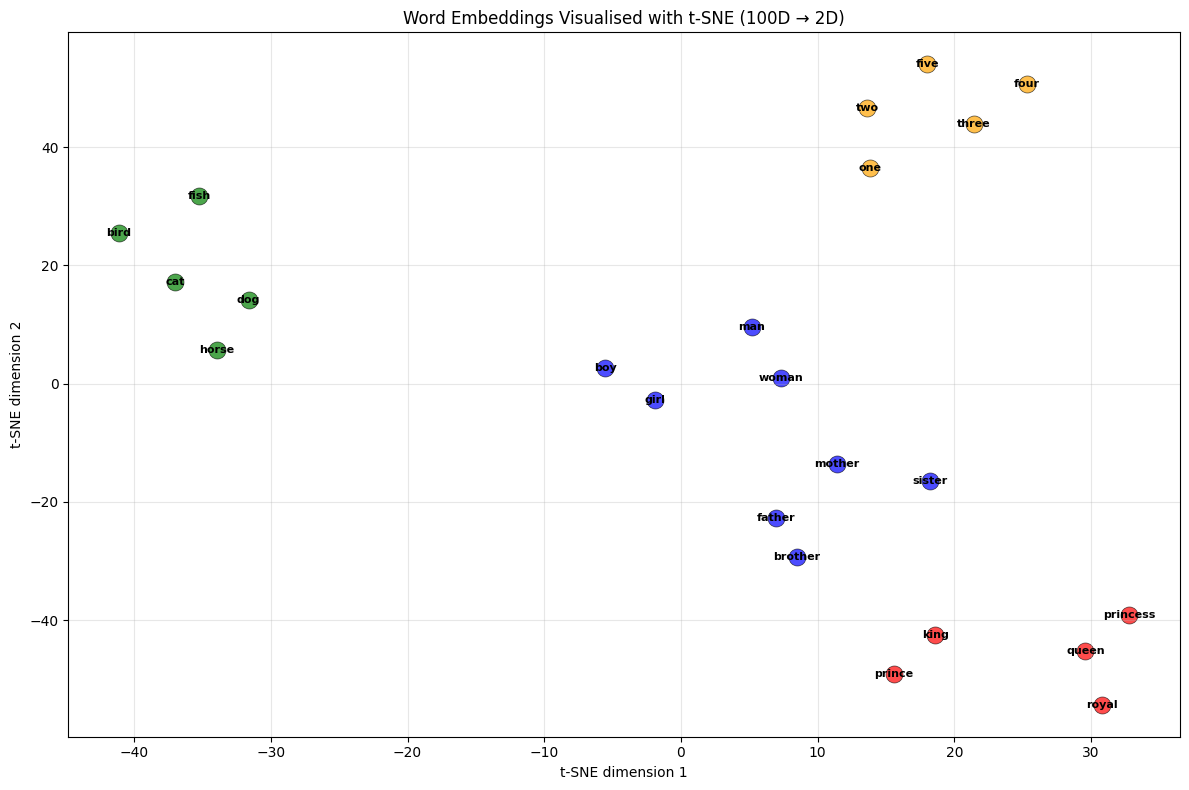


Notice: words of same category cluster together!
Red: royalty, Blue: family/people, Green: animals, Orange: numbers


In [9]:
# t-SNE to 2D (takes a bit longer)
print("Running t-SNE... (this may take 30 seconds)")
tsne = TSNE(n_components=2, random_state=42, perplexity=5, n_iter=1000)
vectors_tsne = tsne.fit_transform(vectors)

# Plot
plt.figure(figsize=(12, 8))

# Color by category
colors = {
    'king': 'red', 'queen': 'red', 'prince': 'red', 'princess': 'red', 'royal': 'red',
    'man': 'blue', 'woman': 'blue', 'boy': 'blue', 'girl': 'blue', 'mother': 'blue', 'father': 'blue', 'sister': 'blue', 'brother': 'blue',
    'cat': 'green', 'dog': 'green', 'bird': 'green', 'fish': 'green', 'horse': 'green',
    'one': 'orange', 'two': 'orange', 'three': 'orange', 'four': 'orange', 'five': 'orange',
}

for i, word in enumerate(words_to_plot):
    plt.scatter(vectors_tsne[i, 0], vectors_tsne[i, 1],
               color=colors[word], s=150, alpha=0.7, edgecolors='black', linewidth=0.5)
    plt.annotate(word, (vectors_tsne[i, 0], vectors_tsne[i, 1]),
                fontsize=8, ha='center', va='center', fontweight='bold')

plt.title("Word Embeddings Visualised with t-SNE (100D → 2D)")
plt.xlabel("t-SNE dimension 1")
plt.ylabel("t-SNE dimension 2")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nNotice: words of same category cluster together!")
print("Red: royalty, Blue: family/people, Green: animals, Orange: numbers")

**Cell 8 — Context-Free Problem**

In [10]:
# Word "bank" has two meanings: financial institution and river bank
# Word2Vec gives it ONE vector — can't distinguish

# Find words similar to "bank"
print("Words similar to 'bank':")
similar_bank = word_vectors.most_similar('bank', topn=10)
for w, score in similar_bank:
    print(f"  {w:<20} {score:.3f}")

print("\n" + "=" * 60)
print("Notice: the results mix both meanings!")
print("- 'savings', 'credit', 'deposit' → financial meaning")
print("- 'river', 'flow' → geographic meaning")
print("\nWord2Vec can't separate these — same word gets one vector.")
print("\nTransformers (BERT, GPT) solve this with CONTEXTUAL embeddings.")
print("'bank' gets different vectors depending on surrounding words.")

Words similar to 'bank':
  banks                0.806
  banking              0.753
  credit               0.704
  investment           0.694
  financial            0.678
  securities           0.669
  lending              0.665
  funds                0.648
  ubs                  0.648
  finance              0.646

Notice: the results mix both meanings!
- 'savings', 'credit', 'deposit' → financial meaning
- 'river', 'flow' → geographic meaning

Word2Vec can't separate these — same word gets one vector.

Transformers (BERT, GPT) solve this with CONTEXTUAL embeddings.
'bank' gets different vectors depending on surrounding words.


**Cell 9 — Analogy Failures**

In [11]:
failed_analogies = [
    ('man', 'woman', 'king'),        # works well
    ('man', 'woman', 'Einstein'),    # fails — Einstein is a person, not a concept
    ('Paris', 'France', 'Rome'),     # should be Italy — works sometimes
    ('run', 'running', 'walk'),      # verb conjugation works well
    ('good', 'bad', 'happy'),        # adjective opposites work
    ('small', 'big', 'ancient'),     # fails — ancient isn't opposite of modern
]

for w1, w2, w3 in failed_analogies:
    try:
        result = word_vectors.most_similar(
            positive=[w3, w2],
            negative=[w1],
            topn=3
        )
        print(f"{w1} : {w2} :: {w3} : {result[0][0]} (score: {result[0][1]:.3f})")
    except KeyError:
        print(f"{w1} : {w2} :: {w3} : [word not found]")

man : woman :: king : queen (score: 0.770)
man : woman :: Einstein : [word not found]
Paris : France :: Rome : [word not found]
run : running :: walk : walking (score: 0.824)
good : bad :: happy : crazy (score: 0.745)
small : big :: ancient : history (score: 0.664)


**Cell 10 — Document Similarity with Embeddings**

In [12]:
# Simple document representation: average of word embeddings
def doc_embedding(doc_text):
    words = doc_text.lower().split()
    valid_words = [w for w in words if w in word_vectors]
    if not valid_words:
        return np.zeros(word_vectors.vector_size)
    return np.mean([word_vectors[w] for w in valid_words], axis=0)

# Test documents
docs = [
    "The cat sat on the mat",
    "A kitten played with a ball",
    "Dogs love to run and play",
    "The quick brown fox jumps",
]

# Get embeddings
doc_embeddings = [doc_embedding(d) for d in docs]

# Compute similarity
from sklearn.metrics.pairwise import cosine_similarity
similarity = cosine_similarity(doc_embeddings)

print("Document similarity (using averaged word embeddings):\n")
print(f"{'Doc':<5} ", end="")
for i in range(len(docs)):
    print(f"D{i}    ", end="")
print()

for i in range(len(docs)):
    print(f"D{i}   ", end="")
    for j in range(len(docs)):
        print(f"{similarity[i, j]:.2f}  ", end="")
    print()

print("\nDocuments 0 and 1 are similar (both about cats)")
print("Documents 2 and 3 are somewhat similar (both about animals/movement)")

Document similarity (using averaged word embeddings):

Doc   D0    D1    D2    D3    
D0   1.00  0.85  0.80  0.80  
D1   0.85  1.00  0.85  0.81  
D2   0.80  0.85  1.00  0.80  
D3   0.80  0.81  0.80  1.00  

Documents 0 and 1 are similar (both about cats)
Documents 2 and 3 are somewhat similar (both about animals/movement)
